In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("creditcard.csv")

# basic info
print(df.shape)
print(df.head())

# check missing values
print(df.isnull().sum())

# statistical summary
print(df.describe())

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

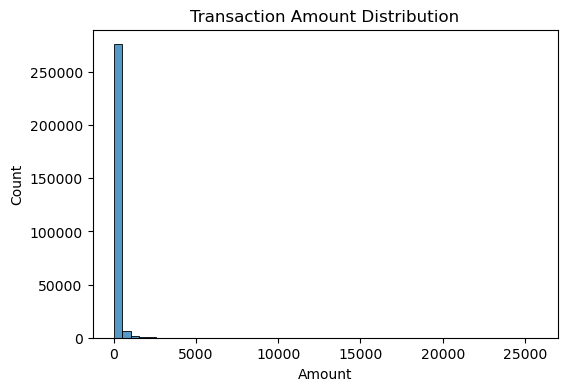

In [3]:
plt.figure(figsize=(6,4))
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

Class
0    284315
1       492
Name: count, dtype: int64


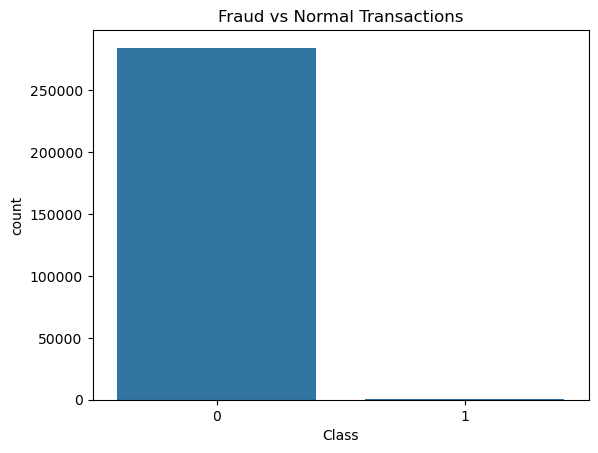

Fraud Percentage: 0.1727485630620034


In [4]:
fraud = df['Class'].value_counts()

print(fraud)

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

print("Fraud Percentage:",
      fraud[1] / len(df) * 100)

In [5]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
X=df.drop(columns="Class")
y=df["Class"]

In [7]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,stratify=y,random_state=42
)

In [9]:
scaler = StandardScaler()

df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [10]:
baseline_model = LogisticRegression(max_iter=2000)

baseline_model.fit(X_train, y_train)

y_pred_base = baseline_model.predict(X_test)

print("Baseline Model Performance")
print(confusion_matrix(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

Baseline Model Performance
[[71066    13]
 [   41    82]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.86      0.67      0.75       123

    accuracy                           1.00     71202
   macro avg       0.93      0.83      0.88     71202
weighted avg       1.00      1.00      1.00     71202



E:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),#for imbalance data use smote
    ('model', LogisticRegression(max_iter=1000))
])

param_grid = {
    'model__C':[0.01,0.1,1,10],
    'model__penalty':['l1','l2'],
    'model__solver':['liblinear']
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall')

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [12]:
y_pred_best = best_model.predict(X_test)

print("Best Model Performance")
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Best Model Performance
[[70359   720]
 [   16   107]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     71079
           1       0.13      0.87      0.23       123

    accuracy                           0.99     71202
   macro avg       0.56      0.93      0.61     71202
weighted avg       1.00      0.99      0.99     71202

